# Proyek Analisis Data: Air Quality Dataset
- **Nama:** Zahra Salma Dwi Meylinda
- **Email:** cdcc200d6x2354@student.devacademy.id
- **ID Dicoding:** CDCC200D6X2354

## Menentukan Pertanyaan Bisnis

- Bagaimana tren konsentrasi PM10 pada seluruh stasiun pengamatan selama periode Maret 2013 hingga Februari 2017, dan pada periode waktu (tahun/bulan) kapan terjadi peningkatan signifikan yang berpotensi menurunkan kualitas udara?
- Bagaimana hubungan antara konsentrasi PM10 dengan faktor lingkungan seperti suhu (TEMP) dan kecepatan angin (WSPM) selama periode Maret 2013 hingga Februari 2017, serta faktor mana yang memiliki pengaruh paling signifikan terhadap perubahan PM10?
- Bagaimana perbedaan tingkat konsentrasi PM10 antar stasiun pengamatan selama periode Maret 2013 hingga Februari 2017, dan stasiun mana yang secara konsisten menunjukkan kualitas udara terburuk?
- Bagaimana distribusi konsentrasi PM10 dan kategorisasi kualitas udara berdasarkan PM10 selama periode Maret 2013 hingga Februari 2017?

## Import Packages yang Digunakan

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import plotly.express as px
import warnings

warnings.filterwarnings("ignore")
sns.set(style="darkgrid")

## Data Wrangling

### Gathering Data

In [2]:
# Menentukan path folder data
data_path = "/content"

# Mengambil seluruh file CSV yang tersedia
csv_files = [file for file in os.listdir(data_path) if file.endswith(".csv")]
csv_files

['PRSA_Data_Changping_20130301-20170228.csv',
 'PRSA_Data_Gucheng_20130301-20170228.csv',
 'PRSA_Data_Dongsi_20130301-20170228.csv',
 'PRSA_Data_Wanshouxigong_20130301-20170228.csv',
 'PRSA_Data_Dingling_20130301-20170228.csv',
 'PRSA_Data_Tiantan_20130301-20170228.csv',
 'PRSA_Data_Wanliu_20130301-20170228.csv',
 'PRSA_Data_Shunyi_20130301-20170228.csv',
 'PRSA_Data_Aotizhongxin_20130301-20170228.csv',
 'PRSA_Data_Huairou_20130301-20170228.csv',
 'PRSA_Data_Guanyuan_20130301-20170228.csv',
 'PRSA_Data_Nongzhanguan_20130301-20170228.csv']

In [3]:
# Menggabungkan seluruh file CSV
df_list = []

for file in csv_files:
    file_path = os.path.join(data_path, file)
    temp_df = pd.read_csv(file_path, na_values=["NA"])
    df_list.append(temp_df)

air_quality_df = pd.concat(df_list, ignore_index=True)

In [4]:
# Membuat kolom datetime dari year, month, day, dan hour
air_quality_df["datetime"] = pd.to_datetime(
    air_quality_df[["year", "month", "day", "hour"]]
)

air_quality_df.head()

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station,datetime
0,1,2013,3,1,0,3.0,6.0,13.0,7.0,300.0,85.0,-2.3,1020.8,-19.7,0.0,E,0.5,Changping,2013-03-01 00:00:00
1,2,2013,3,1,1,3.0,3.0,6.0,6.0,300.0,85.0,-2.5,1021.3,-19.0,0.0,ENE,0.7,Changping,2013-03-01 01:00:00
2,3,2013,3,1,2,3.0,3.0,22.0,13.0,400.0,74.0,-3.0,1021.3,-19.9,0.0,ENE,0.2,Changping,2013-03-01 02:00:00
3,4,2013,3,1,3,3.0,6.0,12.0,8.0,300.0,81.0,-3.6,1021.8,-19.1,0.0,NNE,1.0,Changping,2013-03-01 03:00:00
4,5,2013,3,1,4,3.0,3.0,14.0,8.0,300.0,81.0,-3.5,1022.3,-19.4,0.0,N,2.1,Changping,2013-03-01 04:00:00


**Insight** :
- Dataset terdiri dari beberapa file CSV yang merepresentasikan data kualitas udara dari 12 stasiun pengamatan berbeda.
- Seluruh file berhasil digabungkan menjadi satu dataframe sehingga analisis lintas stasiun dapat dilakukan dengan lebih mudah.
- Dataset memuat variabel polutan seperti PM2.5, PM10, SO2, NO2, CO, dan O3, serta variabel lingkungan seperti suhu (TEMP), tekanan udara (PRES), titik embun (DEWP), curah hujan (RAIN), arah angin (wd), dan kecepatan angin (WSPM).
- Kolom datetime dibentuk dari kombinasi year, month, day, dan hour untuk mendukung analisis berbasis waktu.

### Assessing Data

In [5]:
# Informasi umum dataset
air_quality_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 420768 entries, 0 to 420767
Data columns (total 19 columns):
 #   Column    Non-Null Count   Dtype         
---  ------    --------------   -----         
 0   No        420768 non-null  int64         
 1   year      420768 non-null  int64         
 2   month     420768 non-null  int64         
 3   day       420768 non-null  int64         
 4   hour      420768 non-null  int64         
 5   PM2.5     412029 non-null  float64       
 6   PM10      414319 non-null  float64       
 7   SO2       411747 non-null  float64       
 8   NO2       408652 non-null  float64       
 9   CO        400067 non-null  float64       
 10  O3        407491 non-null  float64       
 11  TEMP      420370 non-null  float64       
 12  PRES      420375 non-null  float64       
 13  DEWP      420365 non-null  float64       
 14  RAIN      420378 non-null  float64       
 15  wd        418946 non-null  object        
 16  WSPM      420450 non-null  float64    

In [6]:
# Mengecek missing values
air_quality_df.isna().sum()

,0
No,0
year,0
month,0
day,0
hour,0
PM2.5,8739
PM10,6449
SO2,9021
NO2,12116
CO,20701


In [7]:
# Mengecek duplikasi
print("Jumlah duplikasi:", air_quality_df.duplicated().sum())

Jumlah duplikasi: 0


In [8]:
# Statistik deskriptif
air_quality_df.describe()

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,WSPM,datetime
count,420768.000000,420768.000000,420768.000000,420768.000000,420768.000000,412029.000000,414319.000000,411747.000000,408652.000000,400067.000000,407491.000000,420370.000000,420375.000000,420365.000000,420378.000000,420450.000000,420768
mean,17532.500000,2014.662560,6.522930,15.729637,11.500000,79.793428,104.602618,15.830835,50.638586,1230.766454,57.372271,13.538976,1010.746982,2.490822,0.064476,1.729711,2015-03-01 11:30:00.000001024
min,1.000000,2013.000000,1.000000,1.000000,0.000000,2.000000,2.000000,0.285600,1.026500,100.000000,0.214200,-19.900000,982.400000,-43.400000,0.000000,0.000000,2013-03-01 00:00:00
25%,8766.750000,2014.000000,4.000000,8.000000,5.750000,20.000000,36.000000,3.000000,23.000000,500.000000,11.000000,3.100000,1002.300000,-8.900000,0.000000,0.900000,2014-03-01 05:45:00
50%,17532.500000,2015.000000,7.000000,16.000000,11.500000,55.000000,82.000000,7.000000,43.000000,900.000000,45.000000,14.500000,1010.400000,3.100000,0.000000,1.400000,2015-03-01 11:30:00
75%,26298.250000,2016.000000,10.000000,23.000000,17.250000,111.000000,145.000000,20.000000,71.000000,1500.000000,82.000000,23.300000,1019.000000,15.100000,0.000000,2.200000,2016-02-29 17:15:00
max,35064.000000,2017.000000,12.000000,31.000000,23.000000,999.000000,999.000000,500.000000,290.000000,10000.000000,1071.000000,41.600000,1042.800000,29.100000,72.500000,13.200000,2017-02-28 23:00:00
std,10122.116943,1.177198,3.448707,8.800102,6.922195,80.822391,91.772426,21.650603,35.127912,1160.182716,56.661607,11.436139,10.474055,13.793847,0.821004,1.246386,NaN


In [9]:
# Mengecek jumlah data per stasiun
air_quality_df["station"].value_counts()

,count
station,
Changping,35064
Gucheng,35064
Dongsi,35064
Wanshouxigong,35064
Dingling,35064
Tiantan,35064
Wanliu,35064
Shunyi,35064
Aotizhongxin,35064


In [10]:
# Mengecek rentang waktu
print("Tanggal awal:", air_quality_df["datetime"].min())
print("Tanggal akhir:", air_quality_df["datetime"].max())

Tanggal awal: 2013-03-01 00:00:00
Tanggal akhir: 2017-02-28 23:00:00


**Insight:**
- Dataset terdiri dari 420.768 baris dan 19 kolom, yang merupakan gabungan data kualitas udara dari 12 stasiun pengamatan selama periode Maret 2013 hingga Februari 2017.
- Jumlah data pada setiap stasiun sama, yaitu 35.064 observasi, sehingga distribusi data antar stasiun dapat dikatakan seimbang.
- Tidak ditemukan data duplikat, sehingga tidak diperlukan penanganan khusus.
- Terdapat missing values pada beberapa variabel, terutama pada CO, O3, NO2, SO2, PM2.5, dan PM10, serta sebagian kecil pada variabel cuaca seperti TEMP dan WSPM. Oleh karena itu, diperlukan proses pembersihan data.
- Berdasarkan statistik deskriptif, nilai PM10 memiliki rentang yang cukup lebar, yang menunjukkan variasi data yang tinggi dan mengindikasikan kemungkinan adanya nilai ekstrem.
- Rentang waktu pengamatan sudah lengkap dan sesuai untuk analisis tren jangka panjang.

### Cleaning Data

In [11]:
# Menghapus kolom tidak relevan
air_quality_df.drop(columns=["No"], inplace=True, errors="ignore")

In [12]:
# Mengurutkan data berdasarkan stasiun dan waktu
air_quality_df = air_quality_df.sort_values(by=["station", "datetime"])

In [13]:
# Mengecek kembali missing values sebelum proses cleaning
air_quality_df.isna().sum()

,0
year,0
month,0
day,0
hour,0
PM2.5,8739
PM10,6449
SO2,9021
NO2,12116
CO,20701
O3,13277


In [14]:
# Threshold cleaning
air_quality_df.loc[air_quality_df["PM10"] > 500, "PM10"] = np.nan
air_quality_df.loc[air_quality_df["PM2.5"] > 500, "PM2.5"] = np.nan
air_quality_df.loc[air_quality_df["CO"] > 5000, "CO"] = np.nan
air_quality_df.loc[air_quality_df["O3"] > 500, "O3"] = np.nan

In [15]:
# Interpolasi kolom numerik utama per stasiun
numeric_interp_cols = ["PM2.5", "PM10", "SO2", "NO2", "CO", "O3",
                       "TEMP", "PRES", "DEWP", "WSPM"]

air_quality_df[numeric_interp_cols] = air_quality_df.groupby("station")[numeric_interp_cols].transform(
    lambda x: x.interpolate(method="linear", limit_direction="both")
)

In [16]:
# Membersihkan kolom RAIN
air_quality_df["RAIN"] = air_quality_df.groupby("station")["RAIN"].transform(
    lambda x: x.fillna(x.median())
)

In [17]:
# Membersihkan kolom wd
air_quality_df["wd"] = air_quality_df.groupby("station")["wd"].transform(
    lambda x: x.fillna(x.mode()[0] if not x.mode().empty else "Unknown")
)

In [18]:
# Cek missing value setelah cleaning
print(air_quality_df.isna().sum())

year        0
month       0
day         0
hour        0
PM2.5       0
PM10        0
SO2         0
NO2         0
CO          0
O3          0
TEMP        0
PRES        0
DEWP        0
RAIN        0
wd          0
WSPM        0
station     0
datetime    0
dtype: int64


In [19]:
print("Jumlah duplikasi:", air_quality_df.duplicated().sum())

Jumlah duplikasi: 0


In [20]:
# Statistik akhir
air_quality_df.describe()

,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,WSPM,datetime
count,420768.000000,420768.000000,420768.000000,420768.000000,420768.000000,420768.000000,420768.000000,420768.000000,420768.000000,420768.000000,420768.000000,420768.000000,420768.000000,420768.000000,420768.000000,420768
mean,2014.662560,6.522930,15.729637,11.500000,79.535909,103.914824,15.913090,50.599018,1191.765320,57.186005,13.531692,1010.753337,2.482421,0.064416,1.730034,2015-03-01 11:30:00.000001024
min,2013.000000,1.000000,1.000000,0.000000,2.000000,2.000000,0.285600,1.026500,100.000000,0.214200,-19.900000,982.400000,-43.400000,0.000000,0.000000,2013-03-01 00:00:00
25%,2014.000000,4.000000,8.000000,5.750000,20.000000,36.000000,3.000000,23.000000,500.000000,10.000000,3.100000,1002.300000,-8.900000,0.000000,0.900000,2014-03-01 05:45:00
50%,2015.000000,7.000000,16.000000,11.500000,55.000000,82.000000,7.000000,43.000000,900.000000,44.000000,14.500000,1010.400000,3.000000,0.000000,1.400000,2015-03-01 11:30:00
75%,2016.000000,10.000000,23.000000,17.250000,111.000000,145.000000,20.000000,71.000000,1500.000000,82.000000,23.300000,1019.000000,15.100000,0.000000,2.200000,2016-02-29 17:15:00
max,2017.000000,12.000000,31.000000,23.000000,500.000000,500.000000,500.000000,290.000000,5000.000000,500.000000,41.600000,1042.800000,29.100000,72.500000,13.200000,2017-02-28 23:00:00
std,1.177198,3.448707,8.800102,6.922195,79.340181,87.816161,21.896609,35.171921,988.240213,56.722848,11.437867,10.474302,13.797675,0.820626,1.246674,NaN


In [21]:
# Simpan dataset
air_quality_df.to_csv("main_data.csv", index=False)

**Insight:**

- Proses pembersihan data difokuskan pada penanganan missing values dan nilai outlier yang ditemukan pada beberapa variabel.
- Untuk variabel numerik yang bersifat kontinu dan berbasis waktu, missing values ditangani menggunakan interpolasi linear per stasiun agar pola perubahan antar waktu tetap terjaga.
- Ditemukan nilai ekstrem yang tidak realistis ( PM10, PM2.5, O3, dan CO dengan nilai sangat tinggi), sehingga dilakukan penanganan dengan mengganti nilai di atas ambang batas tertentu menjadi NaN, kemudian diinterpolasi kembali agar tidak mengganggu distribusi data.
- Variabel RAIN diisi menggunakan median per stasiun karena curah hujan tidak selalu mengikuti pola linear yang stabil.
- Variabel kategorikal wd diisi menggunakan modus per stasiun agar nilai tetap representatif terhadap arah angin dominan di masing-masing stasiun.
- Kolom No dihapus karena hanya berfungsi sebagai nomor urut dan tidak relevan untuk proses analisis.
- Setelah proses cleaning, seluruh missing values berhasil ditangani dan tidak ditemukan data duplikat, sehingga dataset siap digunakan untuk analisis lebih lanjut.

## Exploratory Data Analysis (EDA)

In [22]:
air_quality_df.sample(5)

,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station,datetime
2713,2013,6,22,1,3.0,47.0,5.4264,27.0996,533.333333,60.4044,24.2,999.9,15.9,0.0,NNE,0.9,Changping,2013-06-22 01:00:00
307243,2016,3,18,19,41.0,46.0,2.0000,61.0000,700.000000,51.0000,16.8,1009.0,-7.7,0.0,ENE,1.4,Aotizhongxin,2016-03-18 19:00:00
142957,2013,6,21,13,24.0,57.0,9.0000,20.0000,500.000000,113.0000,31.0,999.7,14.2,0.0,W,1.7,Dingling,2013-06-21 13:00:00
149570,2014,3,24,2,192.0,207.0,22.0000,51.0000,1900.000000,42.0000,8.0,1008.3,-0.5,0.0,NNW,1.1,Dingling,2014-03-24 02:00:00
183770,2014,2,16,2,410.0,387.0,56.0000,120.0000,4500.000000,11.0000,-3.6,1022.3,-5.8,0.0,N,1.5,Tiantan,2014-02-16 02:00:00


In [23]:
air_quality_df.describe()

,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,WSPM,datetime
count,420768.000000,420768.000000,420768.000000,420768.000000,420768.000000,420768.000000,420768.000000,420768.000000,420768.000000,420768.000000,420768.000000,420768.000000,420768.000000,420768.000000,420768.000000,420768
mean,2014.662560,6.522930,15.729637,11.500000,79.535909,103.914824,15.913090,50.599018,1191.765320,57.186005,13.531692,1010.753337,2.482421,0.064416,1.730034,2015-03-01 11:30:00.000001024
min,2013.000000,1.000000,1.000000,0.000000,2.000000,2.000000,0.285600,1.026500,100.000000,0.214200,-19.900000,982.400000,-43.400000,0.000000,0.000000,2013-03-01 00:00:00
25%,2014.000000,4.000000,8.000000,5.750000,20.000000,36.000000,3.000000,23.000000,500.000000,10.000000,3.100000,1002.300000,-8.900000,0.000000,0.900000,2014-03-01 05:45:00
50%,2015.000000,7.000000,16.000000,11.500000,55.000000,82.000000,7.000000,43.000000,900.000000,44.000000,14.500000,1010.400000,3.000000,0.000000,1.400000,2015-03-01 11:30:00
75%,2016.000000,10.000000,23.000000,17.250000,111.000000,145.000000,20.000000,71.000000,1500.000000,82.000000,23.300000,1019.000000,15.100000,0.000000,2.200000,2016-02-29 17:15:00
max,2017.000000,12.000000,31.000000,23.000000,500.000000,500.000000,500.000000,290.000000,5000.000000,500.000000,41.600000,1042.800000,29.100000,72.500000,13.200000,2017-02-28 23:00:00
std,1.177198,3.448707,8.800102,6.922195,79.340181,87.816161,21.896609,35.171921,988.240213,56.722848,11.437867,10.474302,13.797675,0.820626,1.246674,NaN


In [24]:
air_quality_df["station"].value_counts()

,count
station,
Aotizhongxin,35064
Changping,35064
Dingling,35064
Dongsi,35064
Guanyuan,35064
Gucheng,35064
Huairou,35064
Nongzhanguan,35064
Shunyi,35064


In [25]:
air_quality_df["PM10"].describe()

,PM10
count,420768.000000
mean,103.914824
std,87.816161
min,2.000000
25%,36.000000
50%,82.000000
75%,145.000000
max,500.000000


In [26]:
air_quality_df["year"].value_counts().sort_index()

,count
year,
2013,88128
2014,105120
2015,105120
2016,105408
2017,16992


**Insight** : Dataset terdiri dari 420.768 observasi dengan distribusi yang merata di 12 stasiun (masing-masing 35.064 data), sehingga analisis perbandingan antar stasiun dapat dilakukan secara adil tanpa bias jumlah data.

### EDA UNIVARIATE

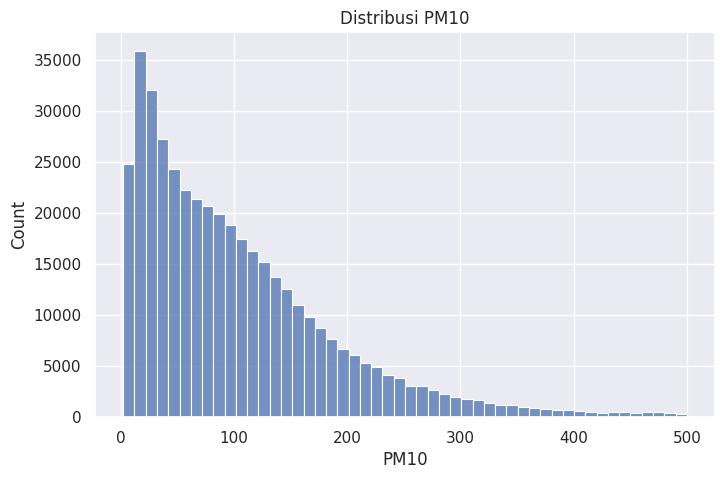

In [27]:
# Histogram PM10
plt.figure(figsize=(8,5))
sns.histplot(air_quality_df["PM10"], bins=50, kde=False)
plt.title("Distribusi PM10")
plt.show()

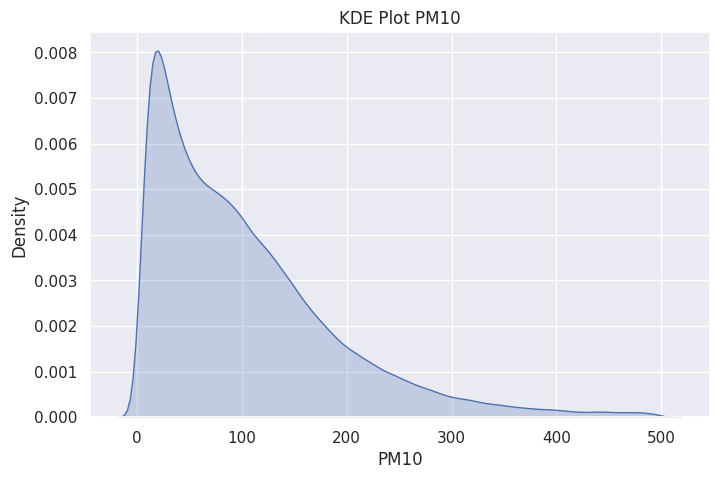

In [28]:
# KDE Plot PM10
plt.figure(figsize=(8,5))
sns.kdeplot(air_quality_df["PM10"], fill=True)
plt.title("KDE Plot PM10")
plt.show()

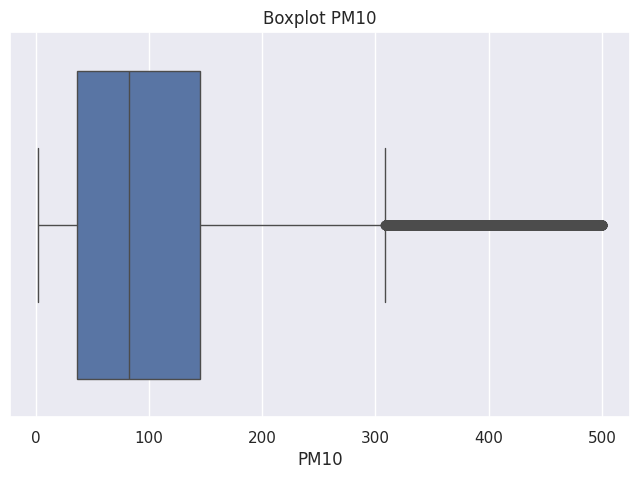

In [29]:
# Boxplot PM10
plt.figure(figsize=(8,5))
sns.boxplot(x=air_quality_df["PM10"])
plt.title("Boxplot PM10")
plt.show()

In [30]:
# Skewness Kurtosis PM10
print("Skewness:", air_quality_df["PM10"].skew())
print("Kurtosis:", air_quality_df["PM10"].kurt())

Skewness: 1.4333214649469954
Kurtosis: 2.3455413441589164


**Insight:**
- Distribusi PM10 menunjukkan skewness positif (~1.44), yang berarti sebagian besar nilai berada pada level rendah hingga sedang, dengan sejumlah nilai tinggi yang lebih jarang.
- Nilai kurtosis (~2.36) mengindikasikan distribusi memiliki ekor yang cukup panjang (heavy tail), namun tidak terlalu ekstrem.
- Histogram dan KDE plot memperlihatkan bahwa distribusi tidak simetris dan tidak mengikuti distribusi normal, dengan ekor panjang ke arah kanan.
- Boxplot menunjukkan adanya outlier pada nilai PM10 yang tinggi, yang mengindikasikan adanya periode dengan konsentrasi polusi udara yang meningkat signifikan.
- Secara keseluruhan, distribusi ini menunjukkan bahwa meskipun kondisi udara sering berada pada level rendah hingga sedang, terdapat kejadian tertentu dengan konsentrasi PM10 tinggi yang perlu diperhatikan dalam analisis kualitas udara.

### EDA TIME SERIES

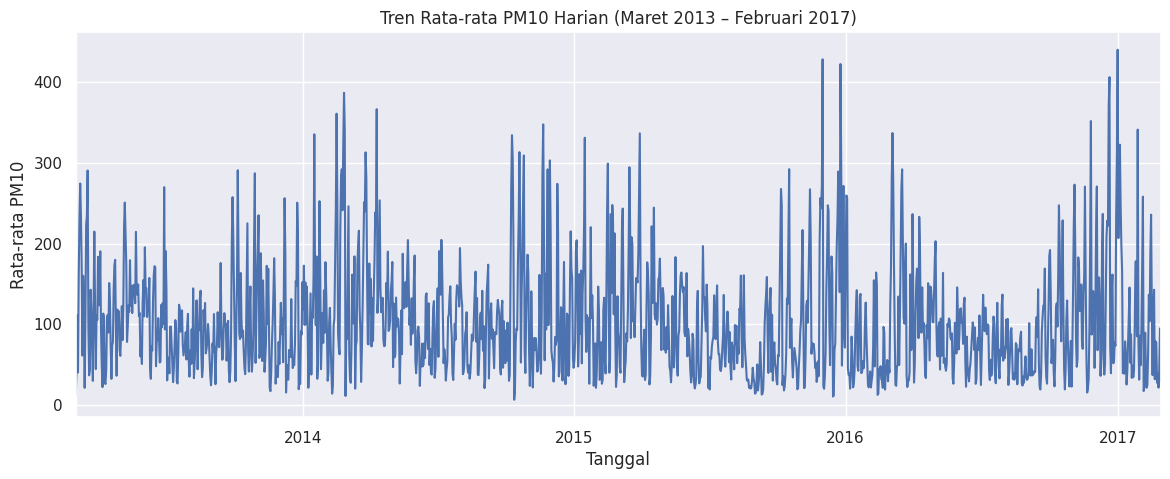

In [31]:
# Menggunakan datetime sebagai index
air_quality_df_ts = air_quality_df.set_index("datetime")

# Menghitung rata-rata PM10 per hari
pm10_daily = air_quality_df_ts["PM10"].resample("D").mean()

# Visualisasi
plt.figure(figsize=(14,5))
pm10_daily.plot()
plt.title("Tren Rata-rata PM10 Harian (Maret 2013 – Februari 2017)")
plt.xlabel("Tanggal")
plt.ylabel("Rata-rata PM10")
plt.show()

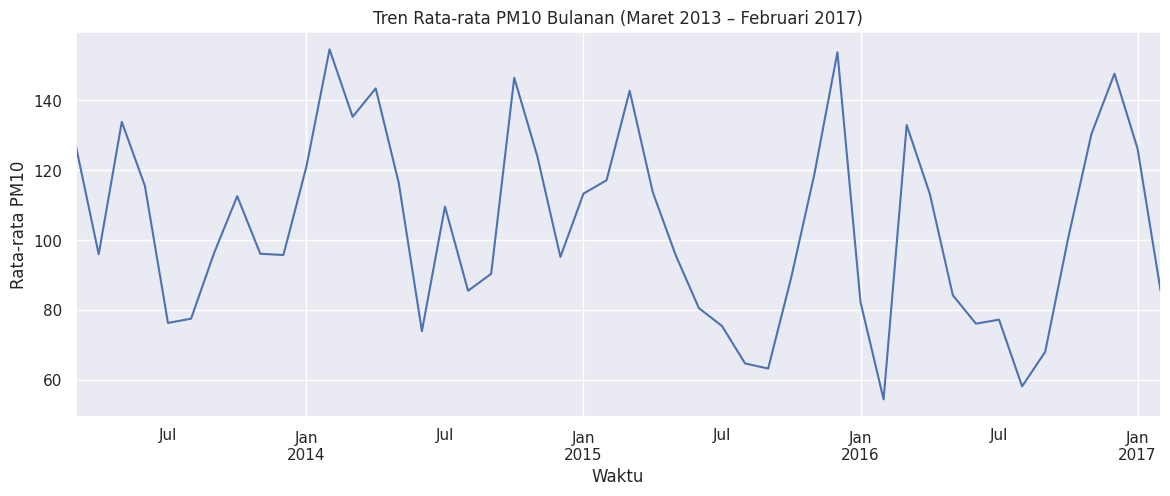

In [32]:
# Rata-rata PM10 per bulan
pm10_monthly = air_quality_df_ts["PM10"].resample("M").mean()

# Visualisasi
plt.figure(figsize=(14,5))
pm10_monthly.plot()
plt.title("Tren Rata-rata PM10 Bulanan (Maret 2013 – Februari 2017)")
plt.xlabel("Waktu")
plt.ylabel("Rata-rata PM10")
plt.show()

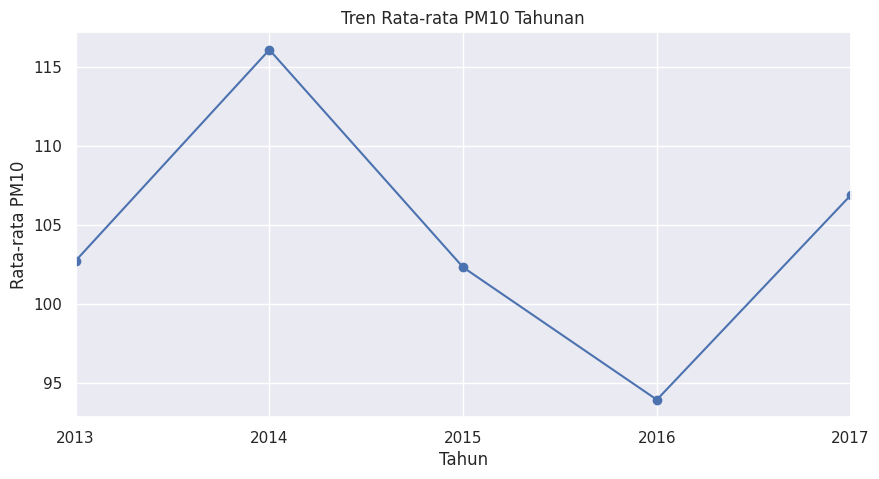

In [33]:
# Rata-rata PM10 per tahun
pm10_yearly = air_quality_df_ts["PM10"].resample("Y").mean()

# Visualisasi
plt.figure(figsize=(10,5))
pm10_yearly.plot(marker='o')
plt.title("Tren Rata-rata PM10 Tahunan")
plt.xlabel("Tahun")
plt.ylabel("Rata-rata PM10")
plt.show()

**Insight**
- Berdasarkan tren harian, konsentrasi PM10 menunjukkan pola yang sangat fluktuatif dengan banyak lonjakan tajam pada waktu-waktu tertentu. Hal ini menunjukkan bahwa kualitas udara dapat berubah secara cepat dalam jangka waktu pendek, kemungkinan dipengaruhi oleh faktor eksternal seperti kondisi cuaca dan aktivitas manusia.

- Analisis pada tingkat bulanan menunjukkan pola yang lebih jelas, di mana terdapat indikasi pola musiman. Konsentrasi PM10 cenderung lebih tinggi pada awal dan akhir tahun dibandingkan pertengahan tahun, yang mengindikasikan adanya pengaruh musim terhadap peningkatan polusi udara.

- Pada tren tahunan, terlihat bahwa nilai rata-rata PM10 mencapai puncaknya pada tahun 2014, kemudian menurun hingga titik terendah pada tahun 2016, sebelum kembali meningkat pada tahun 2017. Hal ini menunjukkan bahwa tidak terdapat tren penurunan kualitas udara yang konsisten dalam jangka panjang.

- Lonjakan PM10 yang terlihat pada grafik harian dan bulanan menunjukkan adanya periode tertentu dengan kualitas udara yang memburuk secara signifikan, yang berpotensi memberikan dampak negatif terhadap kesehatan masyarakat.

- Secara keseluruhan, hasil analisis menunjukkan bahwa kualitas udara selama periode Maret 2013 hingga Februari 2017 bersifat dinamis dan dipengaruhi oleh faktor waktu, dengan adanya fluktuasi jangka pendek (harian), pola musiman (bulanan), serta variasi antar tahun.

## EDA MULTIVARIATE

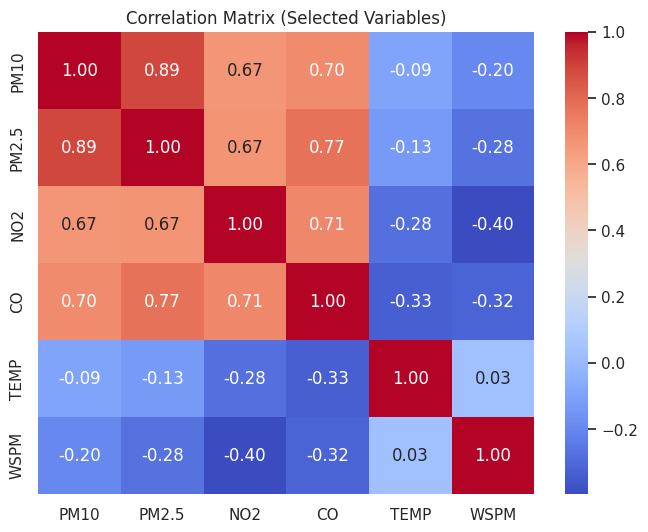

In [34]:
cols = ["PM10", "PM2.5", "NO2", "CO", "TEMP", "WSPM"]

plt.figure(figsize=(8,6))
sns.heatmap(air_quality_df[cols].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix (Selected Variables)")
plt.show()

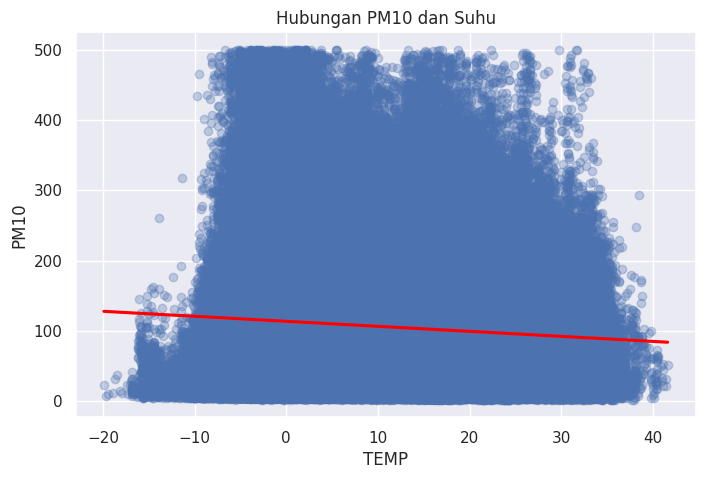

In [35]:
plt.figure(figsize=(8,5))
sns.regplot(x="TEMP", y="PM10", data=air_quality_df, scatter_kws={"alpha":0.3},  line_kws={"color":"red"})
plt.title("Hubungan PM10 dan Suhu")
plt.show()

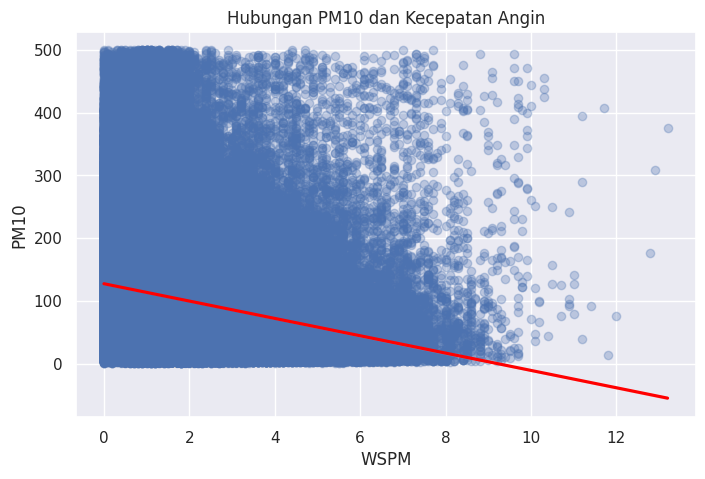

In [36]:
plt.figure(figsize=(8,5))
sns.regplot(x="WSPM", y="PM10", data=air_quality_df, scatter_kws={"alpha":0.3},  line_kws={"color":"red"})
plt.title("Hubungan PM10 dan Kecepatan Angin")
plt.show()

**Insight** :
- Berdasarkan correlation matrix, PM10 menunjukkan korelasi positif yang kuat dengan PM2.5 (~0.89), serta korelasi cukup tinggi dengan CO dan NO2. Hal ini mengindikasikan bahwa peningkatan konsentrasi PM10 cenderung terjadi bersamaan dengan peningkatan polutan lain, yang kemungkinan berasal dari sumber emisi yang sama seperti kendaraan bermotor atau aktivitas industri.
- Kecepatan angin (WSPM) memiliki korelasi negatif terhadap PM10 (~ -0.20), yang menunjukkan bahwa semakin tinggi kecepatan angin, konsentrasi PM10 cenderung menurun. Hal ini konsisten dengan pola pada scatter plot, di mana nilai PM10 cenderung lebih rendah pada kecepatan angin yang lebih tinggi karena efek dispersi polutan.
- Suhu (TEMP) memiliki korelasi yang sangat lemah terhadap PM10 (mendekati nol), sehingga dapat disimpulkan bahwa suhu bukan merupakan faktor utama yang mempengaruhi variasi konsentrasi PM10 dalam dataset ini.
- Scatter plot menunjukkan bahwa hubungan antara PM10 dengan faktor lingkungan masih memiliki sebaran yang luas, sehingga mengindikasikan bahwa selain suhu dan kecepatan angin, terdapat faktor lain yang juga mempengaruhi konsentrasi PM10.
- Secara keseluruhan, perubahan konsentrasi PM10 lebih dipengaruhi oleh keberadaan polutan lain dibandingkan faktor meteorologi, dengan kecepatan angin menjadi faktor lingkungan yang paling berpengaruh meskipun pengaruhnya tidak terlalu kuat.

## EDA PERBANDINGAN ANTAR STASIUN

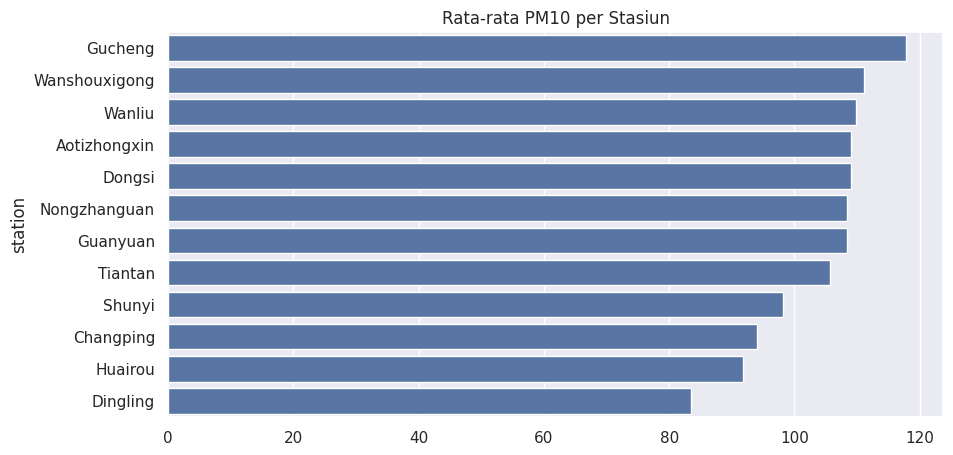

In [37]:
# Rata - rata PM10 per stasiun
station_pm10 = air_quality_df.groupby("station")["PM10"].mean().sort_values(ascending=False)

plt.figure(figsize=(10,5))
sns.barplot(x=station_pm10.values, y=station_pm10.index)
plt.title("Rata-rata PM10 per Stasiun")
plt.show()

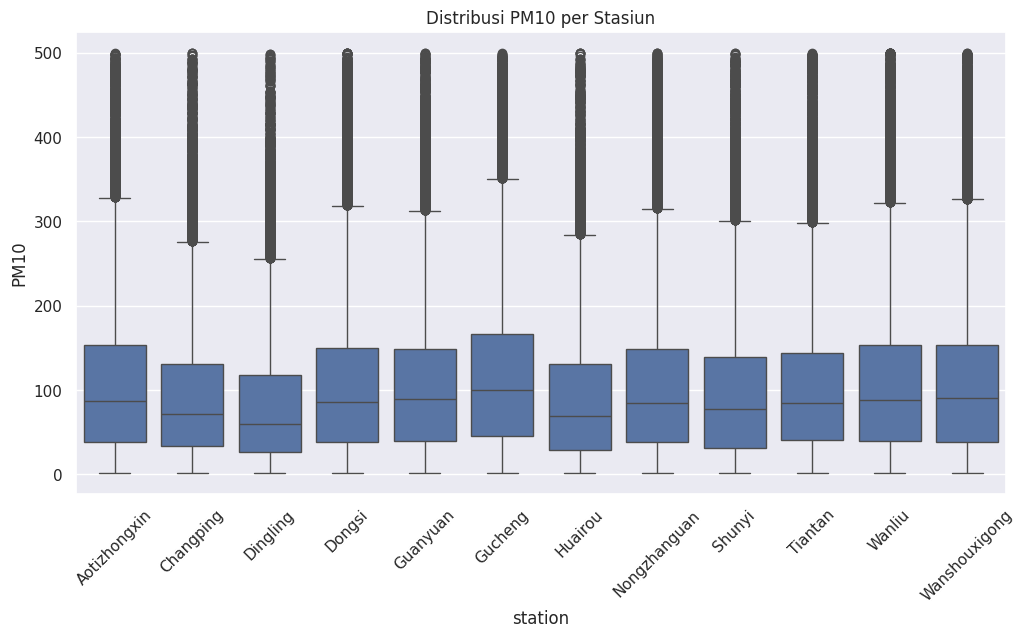

In [38]:
plt.figure(figsize=(12,6))
sns.boxplot(x="station", y="PM10", data=air_quality_df)
plt.xticks(rotation=45)
plt.title("Distribusi PM10 per Stasiun")
plt.show()

**Insight:**
- Distribusi PM10 pada seluruh stasiun menunjukkan adanya banyak nilai ekstrem (outlier), yang terlihat konsisten pada setiap boxplot. Hal ini mengindikasikan bahwa kejadian polusi udara dengan konsentrasi tinggi terjadi di hampir semua lokasi pada waktu-waktu tertentu, sehingga kualitas udara bersifat fluktuatif.
- Berdasarkan nilai rata-rata PM10, stasiun Gucheng memiliki konsentrasi tertinggi, diikuti oleh Wanshouxigong dan Wanliu. Hal ini menunjukkan bahwa stasiun-stasiun tersebut cenderung memiliki kualitas udara yang lebih buruk dibandingkan lokasi lainnya selama periode pengamatan.
- Meskipun terdapat perbedaan nilai rata-rata antar stasiun, distribusi median PM10 relatif tidak berbeda secara signifikan. Hal ini menunjukkan bahwa secara umum pola konsentrasi PM10 antar stasiun cenderung serupa, namun berbeda dalam intensitas tingkat polusinya.
- Keberadaan outlier pada semua stasiun menunjukkan bahwa lonjakan polusi bukan hanya terjadi di satu lokasi tertentu, melainkan merupakan fenomena yang terjadi secara luas di berbagai wilayah.
- Nilai ekstrem (outlier) tidak dihilangkan dalam analisis karena masih merepresentasikan kondisi nyata kualitas udara, terutama saat terjadi episode polusi tinggi, sehingga tetap penting untuk dipertahankan.

## EDA NUMERICAL

In [39]:
air_quality_df["PM10"].describe(percentiles=[0.05, 0.1, 0.9, 0.95])

,PM10
count,420768.000000
mean,103.914824
std,87.816161
min,2.000000
5%,10.000000
10%,16.000000
50%,82.000000
90%,222.000000
95%,279.000000
max,500.000000


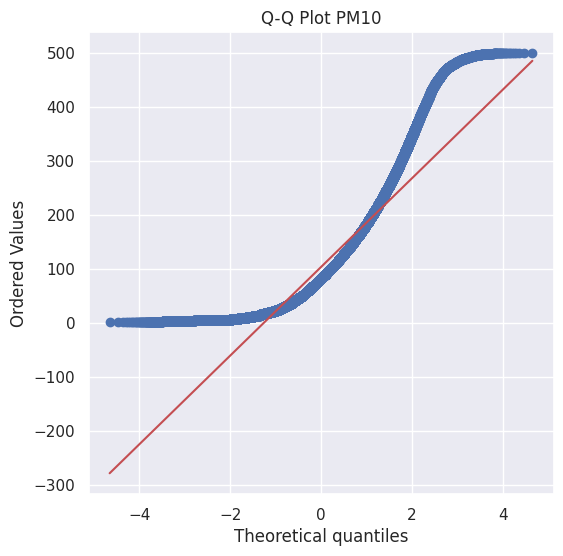

In [40]:
# Q-Q Plot
import scipy.stats as stats

plt.figure(figsize=(6,6))
stats.probplot(air_quality_df["PM10"], dist="norm", plot=plt)
plt.title("Q-Q Plot PM10")
plt.show()

In [41]:
air_quality_df.groupby("station")["PM10"].agg(["mean","std","var"])

,mean,std,var
station,,,
Aotizhongxin,109.086088,90.365213,8165.871691
Changping,94.056129,80.002796,6400.447397
Dingling,83.465542,76.776218,5894.587639
Dongsi,109.070011,92.437892,8544.763842
Guanyuan,108.406030,87.794465,7707.868172
Gucheng,117.876072,91.483512,8369.232999
Huairou,91.719385,81.203047,6593.934872
Nongzhanguan,108.423906,91.805898,8428.322940
Shunyi,98.217221,85.717327,7347.460085


**Insight:**
- Distribusi PM10 tidak normal dan cenderung skew ke kanan, artinya sebagian besar nilai berada di level rendah–sedang, tetapi ada beberapa nilai yang sangat tinggi (outlier).
- Dari analisis persentil, sekitar 90% data berada di bawah ~222 dan 95% di bawah ~279, sehingga nilai di atas itu bisa dianggap sebagai kejadian polusi ekstrem.
- Q-Q plot juga menunjukkan bahwa data menyimpang dari distribusi normal, terutama di bagian nilai tinggi, yang menandakan adanya banyak outlier.
- Dari perbandingan antar stasiun, Gucheng, Wanshouxigong, dan Dongsi memiliki rata-rata PM10 paling tinggi, sehingga bisa dikatakan memiliki kualitas udara yang relatif lebih buruk.
- Beberapa stasiun juga memiliki variasi yang cukup besar (standar deviasi tinggi), yang berarti kondisi kualitas udaranya tidak stabil dan sering berubah.

## EDA KATEGORIKAL

In [42]:
# Kategorisasi PM10
air_quality_df["PM10_category"] = pd.cut(
    air_quality_df["PM10"],
    bins=[0,50,100,150,200,500,1000],
    labels=["Good","Moderate","Unhealthy","Very Unhealthy","Hazardous","Extreme"]
)

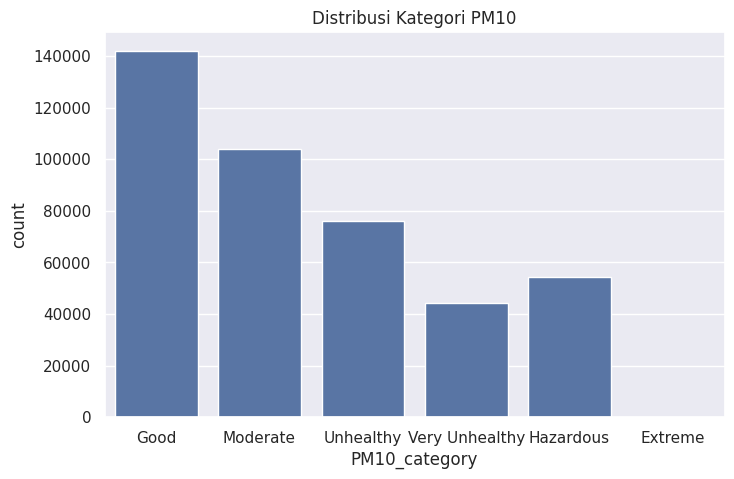

In [43]:
# Distribusi Kategori
plt.figure(figsize=(8,5))
sns.countplot(x="PM10_category", data=air_quality_df)
plt.title("Distribusi Kategori PM10")
plt.show()

In [44]:
# Chi - Square
from scipy.stats import chi2_contingency

contingency = pd.crosstab(air_quality_df["station"], air_quality_df["PM10_category"])
chi2, p, dof, expected = chi2_contingency(contingency)

print("p-value:", p)

p-value: 0.0


**Insight:**

- Distribusi kategori PM10 menunjukkan bahwa sebagian besar data berada pada kategori Good dan Moderate, yang berarti kualitas udara pada umumnya masih tergolong cukup baik.
- Namun, tetap terdapat cukup banyak observasi pada kategori Unhealthy hingga Hazardous, yang menandakan adanya periode tertentu dengan kualitas udara yang buruk dan berpotensi berdampak pada kesehatan.
- Meskipun kategori ekstrem jumlahnya lebih sedikit, keberadaannya penting karena menunjukkan adanya kejadian polusi tinggi yang tidak bisa diabaikan.
- Hasil uji Chi-Square menunjukkan p-value mendekati 0, yang berarti terdapat hubungan signifikan antara stasiun dan kategori PM10. Artinya, kualitas udara memang berbeda antar lokasi dan tidak merata.
- Secara keseluruhan, beberapa stasiun cenderung memiliki kondisi kualitas udara yang lebih buruk dibandingkan yang lain, sehingga perlu perhatian lebih dalam pemantauan dan pengelolaannya.

## Analisis Lanjutan : Analisis Pola Musiman (Seasonality PM10)

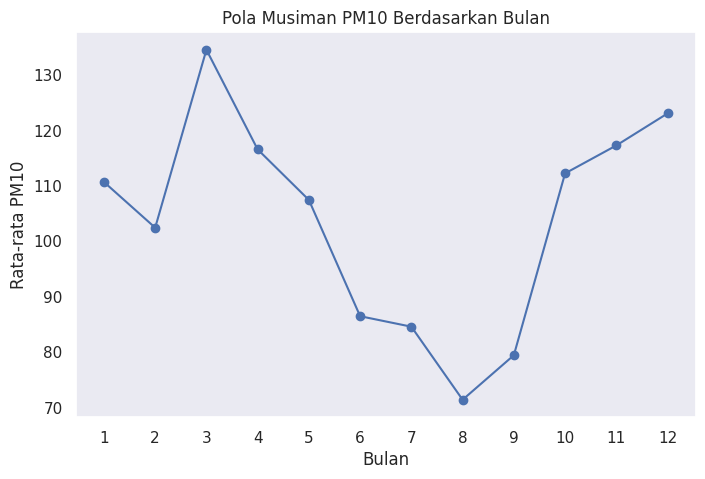

In [45]:
# Menambahkan kolom bulan
air_quality_df["month"] = air_quality_df["datetime"].dt.month

# Menghitung rata-rata PM10 per bulan
monthly_pattern = air_quality_df.groupby("month")["PM10"].mean()

# Visualisasi pola musiman
plt.figure(figsize=(8,5))
monthly_pattern.plot(marker='o')
plt.title("Pola Musiman PM10 Berdasarkan Bulan")
plt.xlabel("Bulan")
plt.ylabel("Rata-rata PM10")
plt.xticks(range(1,13))
plt.grid()
plt.show()

In [46]:
# Bulan dengan PM10 tertinggi
highest_month = monthly_pattern.idxmax()
highest_value = monthly_pattern.max()

# Bulan dengan PM10 terendah
lowest_month = monthly_pattern.idxmin()
lowest_value = monthly_pattern.min()

print("Bulan tertinggi:", highest_month, "dengan PM10:", highest_value)
print("Bulan terendah:", lowest_month, "dengan PM10:", lowest_value)

Bulan tertinggi: 3 dengan PM10: 134.56888720878135
Bulan terendah: 8 dengan PM10: 71.40604838709677


**Insight:**
- Pola musiman menunjukkan bahwa konsentrasi PM10 bervariasi sepanjang tahun.
Nilai PM10 tertinggi terjadi pada bulan Maret, sedangkan terendah pada bulan Agustus.
- Secara umum, konsentrasi PM10 cenderung tinggi di awal dan akhir tahun, dan menurun di pertengahan tahun.
- Pola ini mengindikasikan adanya pengaruh faktor musiman, seperti kondisi cuaca dan aktivitas manusia, terhadap perubahan konsentrasi PM10.
- Temuan ini juga konsisten dengan analisis tren sebelumnya, di mana terdapat periode tertentu dengan peningkatan PM10 yang cukup signifikan.

## Visualization & Explanatory Analysis

### Pertanyaan 1: Bagaimana tren konsentrasi PM10 pada seluruh stasiun pengamatan selama periode Maret 2013 hingga Februari 2017, dan pada periode waktu kapan terjadi peningkatan signifikan?

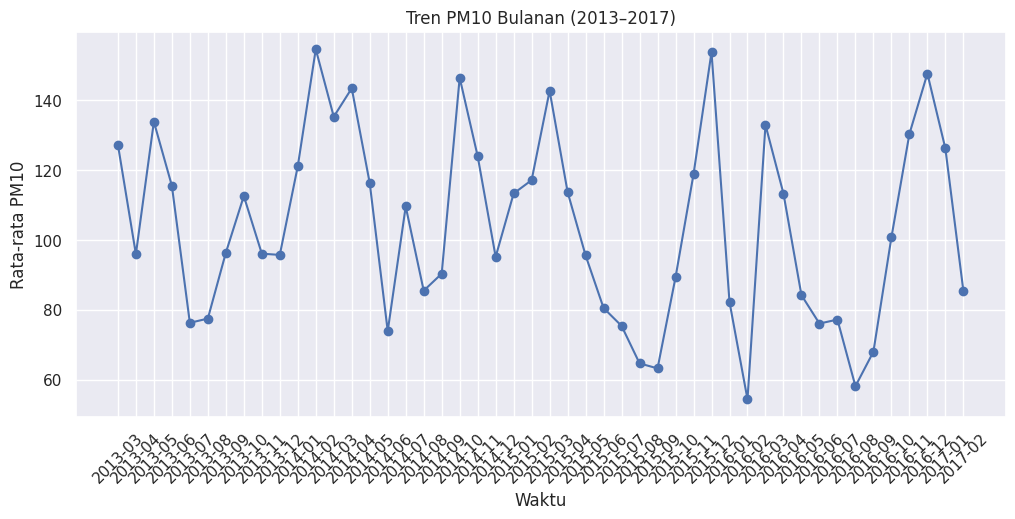

In [47]:
# Agregasi bulanan
pm10_monthly = air_quality_df.resample(rule='M', on='datetime').agg({
    "PM10": "mean"
})

pm10_monthly.index = pm10_monthly.index.strftime('%Y-%m')
pm10_monthly = pm10_monthly.reset_index()

# Visualisasi
plt.figure(figsize=(12,5))
plt.plot(pm10_monthly["datetime"], pm10_monthly["PM10"], marker='o')
plt.xticks(rotation=45)
plt.title("Tren PM10 Bulanan (2013–2017)")
plt.xlabel("Waktu")
plt.ylabel("Rata-rata PM10")
plt.show()

**Insight:**

- Konsentrasi PM10 menunjukkan pola yang fluktuatif sepanjang periode 2013–2017 dengan indikasi pola musiman yang cukup jelas.
- Peningkatan signifikan umumnya terjadi pada akhir hingga awal tahun (sekitar November–Januari), di mana nilai PM10 beberapa kali mencapai puncaknya, terutama pada tahun 2014, 2015, dan 2016.
- Sebaliknya, penurunan konsentrasi PM10 cenderung terjadi pada pertengahan tahun (sekitar Juni–Agustus), yang menunjukkan kondisi kualitas udara yang relatif lebih baik.
- Pola ini menunjukkan bahwa terdapat periode tertentu dalam satu tahun yang secara konsisten mengalami peningkatan polusi, kemungkinan dipengaruhi oleh faktor musiman seperti kondisi cuaca dan aktivitas manusia.

### Pertanyaan 2: Bagaimana hubungan antara konsentrasi PM10 dengan faktor lingkungan seperti suhu (TEMP) dan kecepatan angin (WSPM), serta faktor mana yang paling berpengaruh?

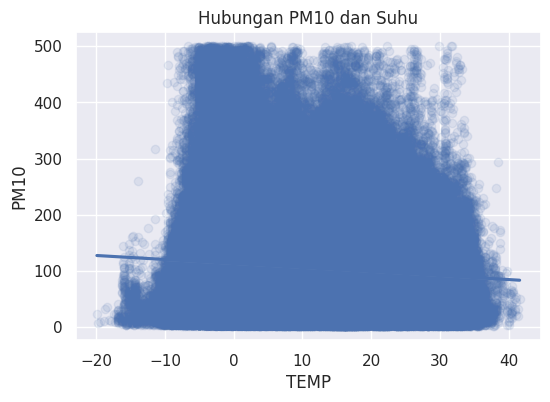

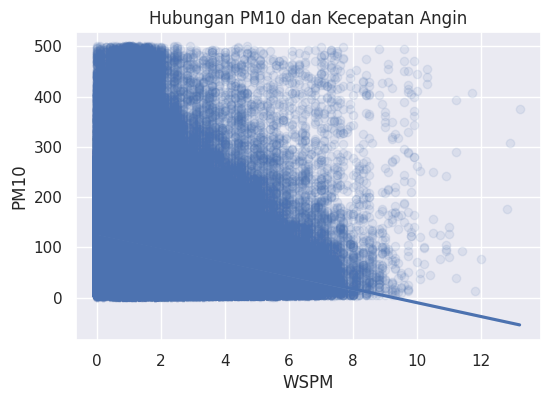

In [48]:
# PM10 vs TEMP
plt.figure(figsize=(6,4))
sns.regplot(x="TEMP", y="PM10", data=air_quality_df, scatter_kws={"alpha":0.1})
plt.title("Hubungan PM10 dan Suhu")
plt.show()

# PM10 vs WSPM
plt.figure(figsize=(6,4))
sns.regplot(x="WSPM", y="PM10", data=air_quality_df, scatter_kws={"alpha":0.1})
plt.title("Hubungan PM10 dan Kecepatan Angin")
plt.show()

**Insight:**
- Hubungan antara suhu (TEMP) dan PM10 terlihat sangat lemah, karena sebaran data tidak menunjukkan pola atau tren yang jelas. Ini menunjukkan bahwa suhu bukan faktor utama yang mempengaruhi perubahan konsentrasi PM10.
- Sebaliknya, kecepatan angin (WSPM) menunjukkan hubungan negatif yang lebih jelas, di mana semakin tinggi kecepatan angin, konsentrasi PM10 cenderung menurun.
- Hal ini mengindikasikan bahwa angin membantu menyebarkan partikel polutan di udara, sehingga mengurangi konsentrasi PM10 di suatu lokasi.
- Berdasarkan hasil tersebut, kecepatan angin (WSPM) merupakan faktor yang lebih berpengaruh dibandingkan suhu (TEMP) dalam mempengaruhi variasi PM10, meskipun pengaruhnya tidak terlalu kuat.

## Pertanyaan 3 : Bagaimana perbedaan tingkat konsentrasi PM10 antar stasiun pengamatan, dan stasiun mana yang menunjukkan kualitas udara terburuk?

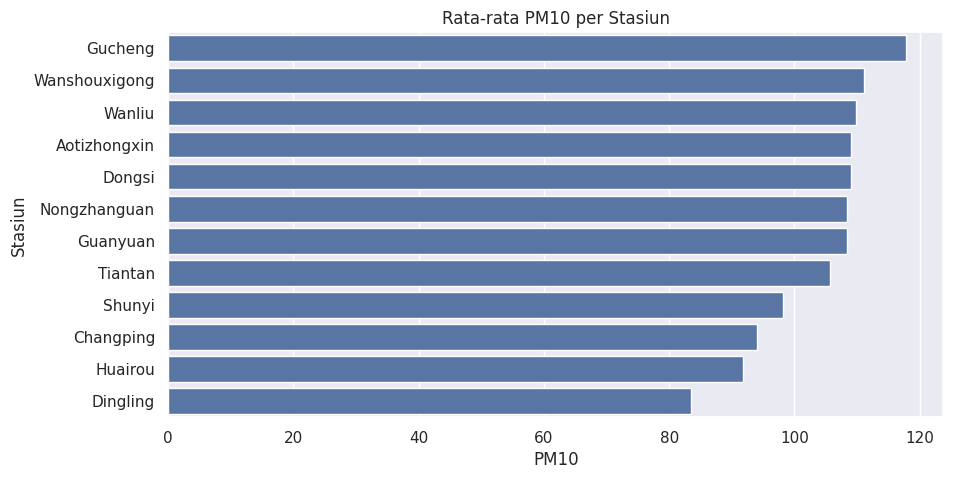

In [49]:
# Rata-rata PM10 per stasiun
station_pm10 = air_quality_df.groupby("station")["PM10"].mean().sort_values(ascending=False)

plt.figure(figsize=(10,5))
sns.barplot(x=station_pm10.values, y=station_pm10.index)
plt.title("Rata-rata PM10 per Stasiun")
plt.xlabel("PM10")
plt.ylabel("Stasiun")
plt.show()

**Insight** :
- Terdapat perbedaan rata-rata konsentrasi PM10 antar stasiun, meskipun selisihnya tidak terlalu besar.
- Stasiun Gucheng memiliki rata-rata PM10 tertinggi, diikuti oleh Wanshouxigong dan Wanliu, yang menunjukkan bahwa wilayah tersebut cenderung memiliki kualitas udara yang lebih buruk.
- Sebaliknya, stasiun Dingling dan Huairou memiliki rata-rata PM10 terendah, sehingga kualitas udaranya relatif lebih baik dibandingkan stasiun lainnya.
- Perbedaan ini kemungkinan dipengaruhi oleh faktor lokasi, seperti tingkat aktivitas manusia, lalu lintas, serta kondisi geografis dan sirkulasi udara di masing-masing wilayah.

## Pertanyaan 4 : Bagaimana distribusi konsentrasi PM10 dan kategorisasi kualitas udara berdasarkan PM10?

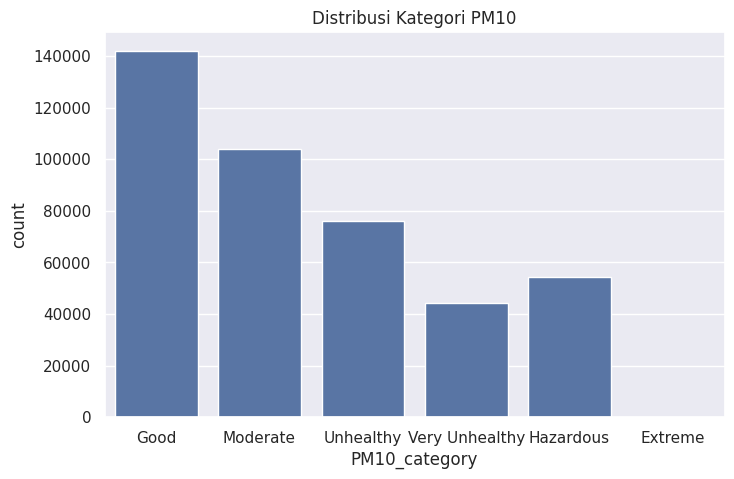

In [50]:
# Kategorisasi PM10
air_quality_df["PM10_category"] = pd.cut(
    air_quality_df["PM10"],
    bins=[0,50,100,150,200,500,1000],
    labels=["Good","Moderate","Unhealthy","Very Unhealthy","Hazardous","Extreme"]
)

# Visualisasi
plt.figure(figsize=(8,5))
sns.countplot(x="PM10_category", data=air_quality_df)
plt.title("Distribusi Kategori PM10")
plt.show()

**Insight:**
- Sebagian besar data PM10 berada pada kategori Good dan Moderate, yang menunjukkan bahwa secara umum kualitas udara masih berada pada tingkat aman hingga sedang.
- Namun, terdapat cukup banyak observasi pada kategori Unhealthy hingga Hazardous, yang menandakan adanya periode dengan kualitas udara yang buruk dan berpotensi berdampak pada kesehatan.
- Kategori Extreme hampir tidak muncul, sehingga kejadian polusi yang sangat parah tergolong jarang selama periode pengamatan.
- Secara keseluruhan, meskipun kondisi udara sering berada di kategori aman, tetap terdapat fluktuasi menuju kondisi tidak sehat yang perlu diperhatikan.

## Conclusion

- **Conclution pertanyaan 1**: Konsentrasi PM10 selama periode Maret 2013–Februari 2017 bersifat fluktuatif dan menunjukkan pola musiman. Nilai cenderung meningkat pada awal hingga akhir tahun (sekitar November–Maret) dan menurun pada pertengahan tahun (Juni–Agustus). Hal ini menunjukkan bahwa kualitas udara dipengaruhi oleh faktor musiman.

- **Conclution pertanyaan 2**: Hubungan antara PM10 dan suhu (TEMP) tergolong lemah sehingga suhu bukan faktor utama yang mempengaruhi perubahan PM10. Sebaliknya, kecepatan angin (WSPM) memiliki hubungan negatif, di mana semakin tinggi kecepatan angin, konsentrasi PM10 cenderung menurun. Dengan demikian, WSPM lebih berpengaruh dibandingkan TEMP.

- **Conclusion pertanyaan 3**: Terdapat perbedaan konsentrasi PM10 antar stasiun. Stasiun Gucheng memiliki rata-rata tertinggi, diikuti Wanshouxigong dan Wanliu, sehingga menunjukkan kualitas udara yang lebih buruk. Sebaliknya, Dingling dan Huairou memiliki rata-rata lebih rendah, sehingga kualitas udaranya relatif lebih baik. Gucheng dapat dianggap sebagai lokasi dengan kondisi udara terburuk.

- **Conclusion pertanyaan 4** : Distribusi PM10 didominasi kategori Good dan Moderate, yang menunjukkan kondisi udara umumnya masih aman hingga sedang. Namun, masih terdapat cukup banyak kategori Unhealthy hingga Hazardous, yang menandakan adanya periode dengan kualitas udara buruk. Kategori Extreme jarang terjadi, tetapi tetap menunjukkan potensi kejadian polusi tinggi.

### Rekomendasi

- Fokus pengendalian polusi pada periode November–Maret karena konsentrasi PM10 cenderung meningkat.
- Manfaatkan kecepatan angin sebagai indikator dalam mitigasi polusi, terutama saat kondisi angin rendah.
- Prioritaskan wilayah dengan PM10 tinggi seperti Gucheng untuk pengendalian emisi.
- Meskipun mayoritas kondisi udara aman, tetap diperlukan langkah preventif untuk mengantisipasi lonjakan ke kategori berbahaya.